In [1]:
import sys
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from src.data_preprocessing import load_data, load_rf
import importlib
import os
importlib.reload(sys)

<module 'sys' (built-in)>

In [2]:
# Config
DATA_PATH = "data/raw/Portfolio Optimisation - EF.xlsm"
RETURNS_PATH = "data/cleaned/monthly_returns.csv"
PARAMETERS_PATH = "parameters/"
FIGURE_PATH = "results/"

In [3]:
# load datasets
datasets = load_data(file=DATA_PATH, output_dir="data/cleaned")

Loaded tables:
monthly_returns           shape=(297, 10)
summary_statistics        shape=(8, 10)
accumulated_value         shape=(297, 10)
asset_class_metadata      shape=(9, 6)
cost_fees                 shape=(9, 3)
adjusted_returns          shape=(297, 9)


/Users/kennyyu/miniconda3/envs/fmat3888/lib/python3.10/site-packages/pandas/core/indexes/base.py:7654: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


In [4]:
# load risk-free rate
rf = load_rf(datasets["monthly_returns"], "data/cleaned", True)

Saved RF shape=(297, 1)


In [5]:
returns = pd.read_csv(RETURNS_PATH, index_col=0).astype(float)
returns.index = pd.to_datetime(returns.index)
cut_date = pd.Timestamp("2021-01-29")
returns_train = returns.loc[returns.index < cut_date]
returns_test = returns.loc[returns.index >= cut_date]

In [6]:
from src.parameter_estimation import LatentAutoencoder

model = LatentAutoencoder(data_path=RETURNS_PATH, output_dir=PARAMETERS_PATH, figure_path=FIGURE_PATH)
model.estimate_parameters()

===Running Factors Autoencoder===
===Window 1===
Epoch [100/500] | Loss: 0.115172
Epoch [200/500] | Loss: 0.059454
Epoch [300/500] | Loss: 0.036041
Epoch [400/500] | Loss: 0.042044
Epoch [500/500] | Loss: 0.035384
===Window 2===
Epoch [100/500] | Loss: 0.104497
Epoch [200/500] | Loss: 0.082027
Epoch [300/500] | Loss: 0.039875
Epoch [400/500] | Loss: 0.036737
Epoch [500/500] | Loss: 0.029592
===Window 3===
Epoch [100/500] | Loss: 0.112112
Epoch [200/500] | Loss: 0.055519
Epoch [300/500] | Loss: 0.034447
Epoch [400/500] | Loss: 0.033377
Epoch [500/500] | Loss: 0.026491
===Window 4===
Epoch [100/500] | Loss: 0.104669
Epoch [200/500] | Loss: 0.053424
Epoch [300/500] | Loss: 0.038345
Epoch [400/500] | Loss: 0.035409
Epoch [500/500] | Loss: 0.041251
===Window 5===
Epoch [100/500] | Loss: 0.123830
Epoch [200/500] | Loss: 0.049114
Epoch [300/500] | Loss: 0.046794
Epoch [400/500] | Loss: 0.038261
Epoch [500/500] | Loss: 0.039393
===Window 6===
Epoch [100/500] | Loss: 0.254126
Epoch [200/500] | 

Figure saved to results/


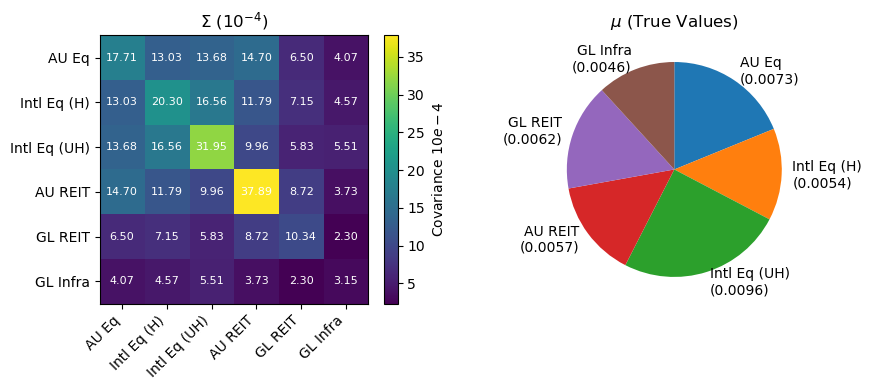

In [7]:
model.visualise_parameters(
    asset_labels=[
        "AU Eq",
        "Intl Eq (H)",
        "Intl Eq (UH)",
        "AU REIT",
        "GL REIT",
        "GL Infra"
    ],
    growth_flag=True
)

In [11]:
Sigma = model.Sigma_latent
np.linalg.inv(Sigma)

array([[1434.63939373, -451.23655292, -192.10698849, -292.15152771,
        -143.20017248, -412.68476614],
       [-451.23655292, 1261.70093946, -324.89743688,  -22.2022424 ,
        -288.62133348, -442.76014877],
       [-192.10698849, -324.89743688,  617.89007566,   44.21835415,
          61.65993696, -459.26071753],
       [-292.15152771,  -22.2022424 ,   44.21835415,  414.68438573,
        -167.49333243,  -36.31231946],
       [-143.20017248, -288.62133348,   61.65993696, -167.49333243,
        1443.01430195, -359.71403693],
       [-412.68476614, -442.76014877, -459.26071753,  -36.31231946,
        -359.71403693, 5466.54129316]])

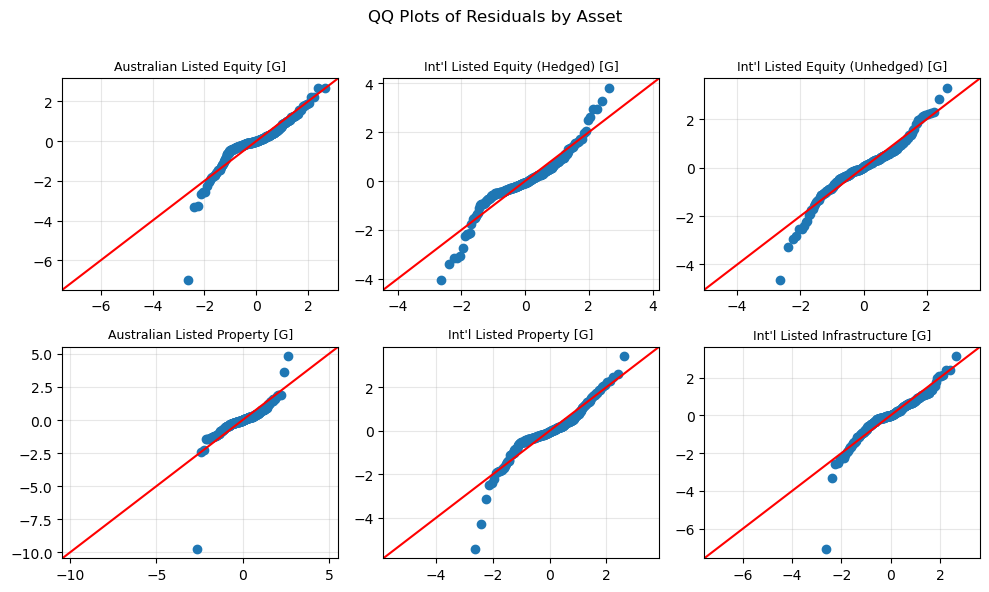

In [8]:
model.plot_qq_residuals()

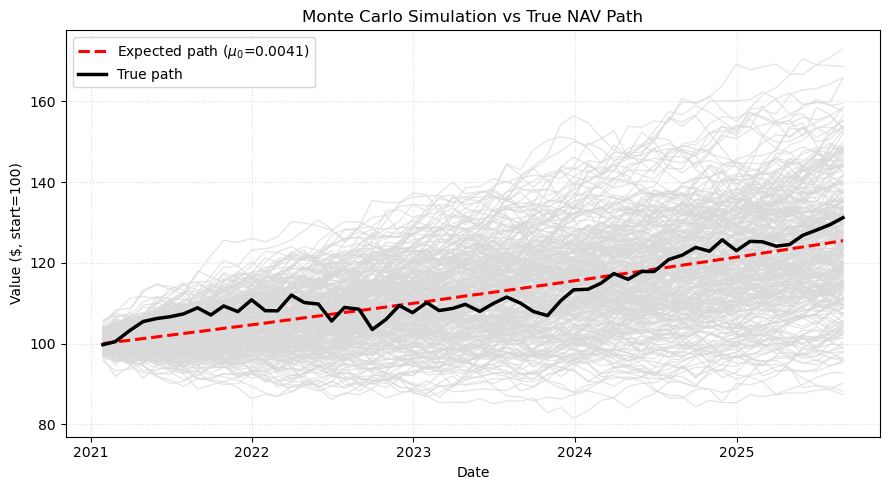

{'n': 56, 'mu0': 0.00413373464888031, 'sigma0': 0.0182449070314463}

In [9]:
w_growth = np.array([0.3, 0.159, 0.096, 0.016, 0.009, 0.21, 0.21 ])
model.plot_mc_after_cut(w_growth[1:])

Saved figure to results/nav_vs_mu_predicted.png


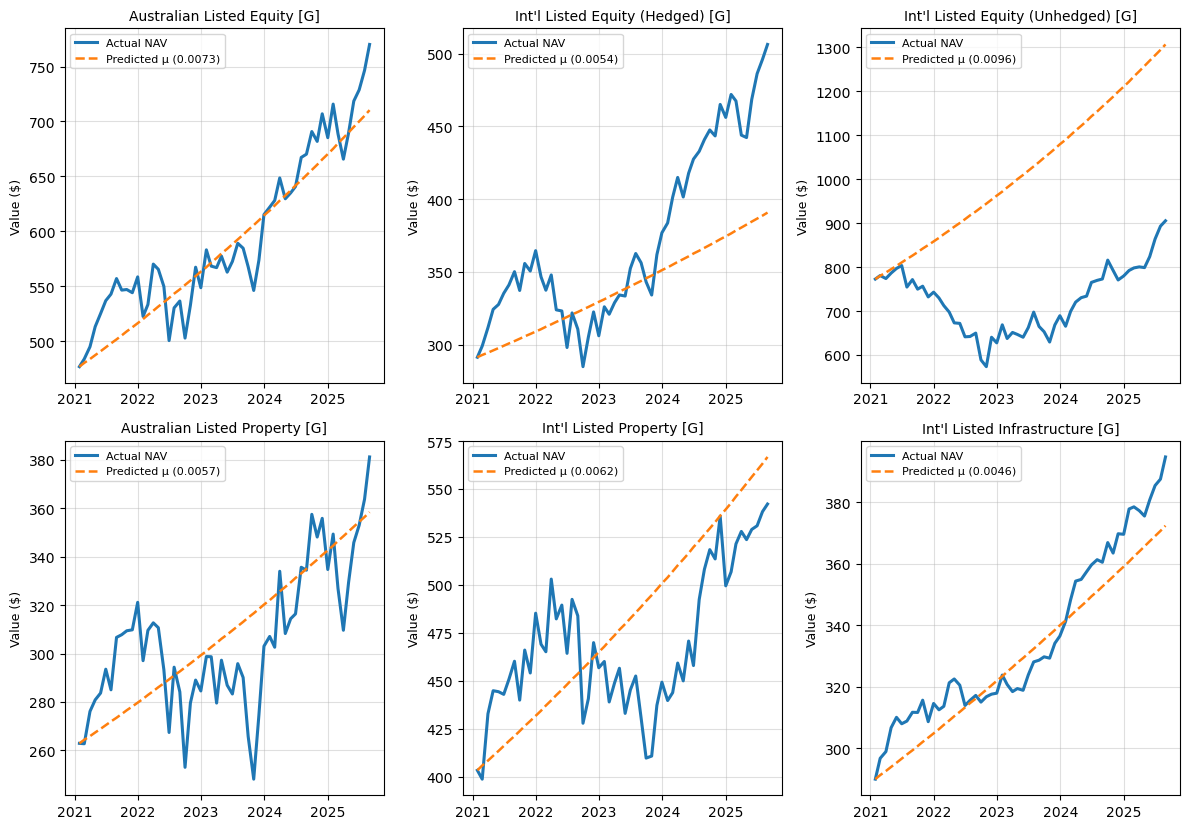

,mu_latent
Australian Listed Equity [G],0.007277
Int'l Listed Equity (Hedged) [G],0.005351
Int'l Listed Equity (Unhedged) [G],0.009598
Australian Listed Property [G],0.005655
Int'l Listed Property [G],0.006204
Int'l Listed Infrastructure [G],0.004551


In [10]:
model.plot_nav_mu_growth(cut_date="2021-01-29")